# Week 4 — alert volume and capacity (Wednesday, 1 hour)

Seven exercises on the studio's **capacity model**. Everything calls fc-10's own `capacity` module and Decision Log.
The assumptions are Decision 2's: 300 reviews a day at bank scale, TM-SIM read as a 1-in-150 sample (**2.0 per
working day**), and one alert per customer-month. Every rate is against **PLANTED TRUTH**.

Run with `FC10_REPOSITORY` set (see `training/README.md`). Read `README.md` in this folder first.

In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parents[1]))
from tools.tm_sim_source import load, fc10_module

tm_sim, metrics = load()
capacity = fc10_module("runtime.manufacturing.tuning.capacity")
decision_log = fc10_module("runtime.manufacturing.tuning.decision_log")

pop = tm_sim.generate()
CAP = capacity.sample_capacity(300, 150)          # 2.0 reviews per working day in the sample
days = capacity.calendar(pop)
WD = capacity.working_days(days)
TODAY = 75_000
print(f"capacity {CAP} per working day · {WD} working days · budget {CAP * WD:.0f} customer-months a year")

capacity 2.0 per working day · 261 working days · budget 522 customer-months a year


## Exercise 1 — what counts as one alert?

The same rule at £95,000, counted three ways, month by month. Look at October under "first alert per year": that isn't
behaviour, it's the start of the window.

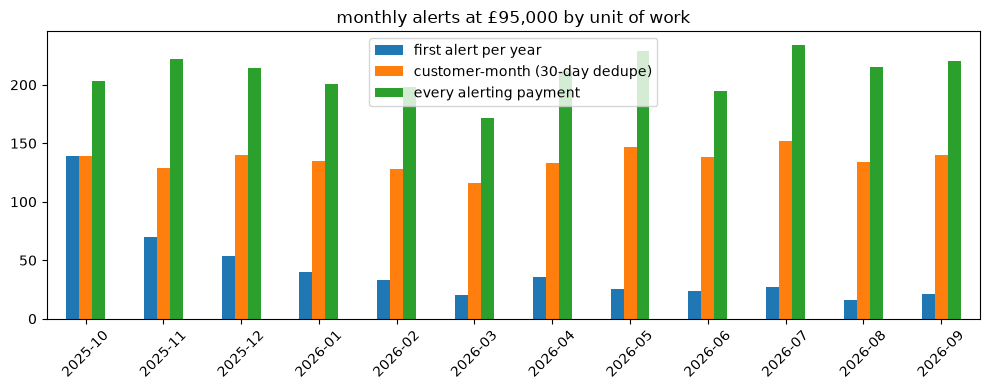

first alert per year               505
customer-month (30-day dedupe)    1631
every alerting payment            2515
Name: per year, dtype: int64

In [2]:
T = 95_000
over = [t for t in pop.transactions if t.amount > T]
first_year, first_month = {}, {}
for t in over:
    first_year.setdefault(t.customer_id, t.value_date)
    first_month.setdefault((t.customer_id, t.value_date[:7]), t.value_date)
grains = pd.DataFrame({
    "first alert per year": Counter(d[:7] for d in first_year.values()),
    "customer-month (30-day dedupe)": Counter(d[:7] for d in first_month.values()),
    "every alerting payment": Counter(t.value_date[:7] for t in over),
}).sort_index()
grains.plot.bar(figsize=(10, 4), rot=45, title=f"monthly alerts at £{T:,} by unit of work"); plt.tight_layout(); plt.show()
grains.sum().rename("per year")

## Exercise 2 — the capacity frontier

Workload per working day against the threshold, with capacity drawn across it. The frontier is the best recall on
the right-hand side of the crossing.

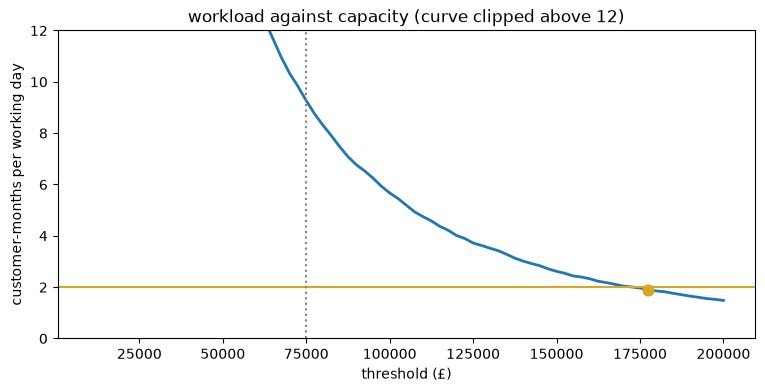

,today,operating point
threshold,75000,177500
workload,2419,498
workload_per_working_day,9.268199,1.908046
recall,0.55,0.325
precision,0.162003,0.300926


In [3]:
f = capacity.frontier(pop, "high_value", CAP)
fr = pd.DataFrame(f["points"])
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(fr.threshold, fr.workload_per_working_day, lw=2)
ax.axhline(CAP, c="goldenrod"); ax.axvline(TODAY, c="grey", ls=":")
op = f["operating_point"]
ax.scatter([op["threshold"]], [op["workload_per_working_day"]], c="goldenrod", zorder=3, s=60)
ax.set_ylim(0, 12); ax.set_xlabel("threshold (£)"); ax.set_ylabel("customer-months per working day")
ax.set_title("workload against capacity (curve clipped above 12)"); plt.show()
pd.DataFrame({"today": f["today"], "operating point": op}).loc[["threshold", "workload", "workload_per_working_day", "recall", "precision"]]

## Exercise 3 — the queue, day by day

The backlog over the year at today's line and at the frontier. One of them never recovers.

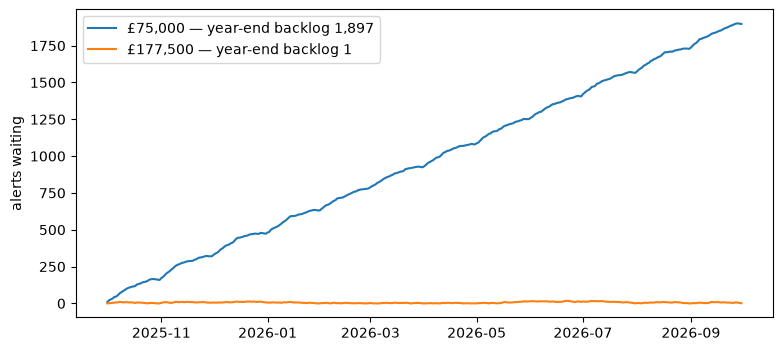

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for t in (TODAY, op["threshold"]):
    q = capacity.simulate_queue(capacity.daily_arrivals(pop, t), days, CAP)
    per = pd.DataFrame(q["per_day"]); per["date"] = pd.to_datetime(per.date)
    ax.plot(per.date, per.backlog, label=f"£{t:,} — year-end backlog {q['backlog_end']:,}")
ax.set_ylabel("alerts waiting"); ax.legend(); plt.show()

## Exercise 4 — Little's law

Over a long run, **average backlog ≈ arrival rate × average wait**. Check it at the frontier, where the queue is
stable. (At today's line it isn't stable, and the law's premise fails. Try it and see why.)

In [5]:
q = capacity.simulate_queue(capacity.daily_arrivals(pop, op["threshold"]), days, CAP)
per = pd.DataFrame(q["per_day"])
work_days = per[pd.to_datetime(per.date).dt.weekday < 5]
L = work_days.backlog.mean()                      # average backlog, sampled on working days
lam = q["arrived"] / WD                           # arrivals per working day
W = np.mean(q["waits"])                           # average wait, working days
pd.Series({"average backlog L": L, "arrival rate λ": lam, "average wait W": W, "λ × W": lam * W}).round(2)

average backlog L    5.63
arrival rate λ       1.91
average wait W       2.95
λ × W                5.63
dtype: float64

## Exercise 5 — effective recall: the inversion

Alerted recall assumes somebody looks. Effective recall counts only alerts that were actually worked, in the year and
within 10 working days. Watch the lines cross.

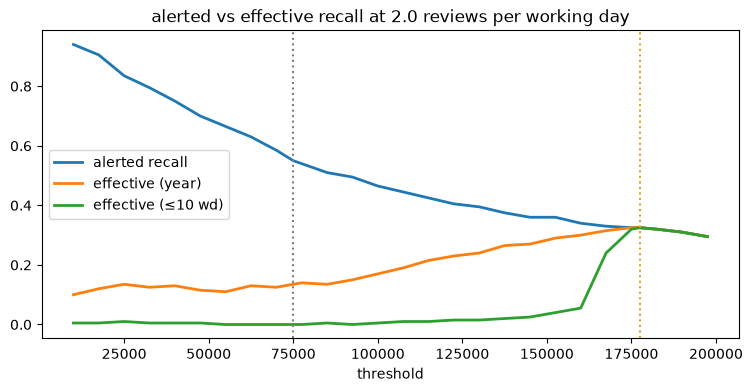

,alerted recall,effective (year),effective (≤10 wd)
threshold,,,
75000,0.550,0.135,0.000
177500,0.325,0.325,0.325


In [6]:
rows = []
by_t = {p["threshold"]: p for p in f["points"]}
sample = sorted({p["threshold"] for p in f["points"][::3]} | {TODAY, op["threshold"]})
for t in sample:
    p = by_t[t]
    rows.append({"threshold": t, "alerted recall": p["recall"],
                 "effective (year)": capacity.effective_recall(pop, t, CAP),
                 "effective (≤10 wd)": capacity.effective_recall(pop, t, CAP, sla_working_days=10)})
eff = pd.DataFrame(rows).set_index("threshold")
eff.plot(figsize=(9, 4), lw=2, title="alerted vs effective recall at 2.0 reviews per working day")
plt.axvline(TODAY, c="grey", ls=":"); plt.axvline(op["threshold"], c="goldenrod", ls=":"); plt.show()
eff.loc[[TODAY, op["threshold"]]]

## Exercise 6 — the staffing curve

Keep the rule, vary the team. For bank-scale capacity from 150 to 1,500 reviews a day: where does the frontier sit,
and what does today's £75,000 line actually catch?

In [7]:
rows = []
for bank in (150, 300, 450, 600, 900, 1200, 1400, 1500):
    c = capacity.sample_capacity(bank, 150)
    fb = capacity.frontier(pop, "high_value", c)
    o = fb["operating_point"]
    rows.append({"bank reviews/day": bank,
                 "frontier threshold": None if o is None else o["threshold"],
                 "frontier effective recall": None if o is None else capacity.effective_recall(pop, o["threshold"], c),
                 "£75k effective recall": capacity.effective_recall(pop, TODAY, c),
                 "£75k within 10 wd": capacity.effective_recall(pop, TODAY, c, sla_working_days=10)})
pd.DataFrame(rows).set_index("bank reviews/day")

,frontier threshold,frontier effective recall,£75k effective recall,£75k within 10 wd
bank reviews/day,,,,
150,NaN,NaN,0.065,0.000
300,177500.0,0.325,0.135,0.000
450,142500.0,0.365,0.195,0.005
600,122500.0,0.400,0.245,0.020
900,97500.0,0.460,0.385,0.030
1200,82500.0,0.510,0.485,0.115
1400,75000.0,0.545,0.545,0.545
1500,72500.0,0.570,0.550,0.550


## Exercise 7 — what Decision 2 recorded

Read straight from fc-10's log. Its figures were computed from the stated assumptions, not typed, and this repository's
parity test re-derives every one of them with an independent queue.

In [8]:
[d2] = [e for e in decision_log.load() if e["decision_id"] == "D2"]
print(d2["decision"], "at", f"£{d2['to_threshold']:,}", "—", d2["date"], "— assumptions:", d2["assumptions"])
print("\n", d2["rationale"]); print("\nrevisit:", d2["revisit"])

HOLD at £75,000 — 2026-09-25 — assumptions: {'bank_capacity_per_day': 300, 'sample_ratio': 150, 'sla_working_days': 10}

 Held at GBP 75,000 and the capacity gap named instead. On the stated assumptions -- 300 reviews a day at bank scale, TM-SIM a 1-in-150 sample (2.0 per working day), one alert per customer-month -- today's line makes 2,419 customer-months of work a year, 4.63x capacity. The queue ends the year 1,897 behind and effective recall is 0.135, none of it within 10 working days. The capacity frontier (GBP 177,500) would lift effective recall to 0.325, but the owner chose to keep the line and resource the team: holding it needs about 1,390 reviews a day at bank scale.

revisit: A staffing ask, outside tuning: about 1,390 reviews a day at bank scale to hold GBP 75,000. Until it is met the drowned queue is the known state. Revisit with Decision 4 (week 6), where a customer-baseline challenger may change how much work the line makes.


## Your answers (the curriculum's success criteria)

1. **What unit of work did you choose for capacity, and what would the other two have told you?** Use Exercise 1.

    *…*

2. **Under 300 reviews a day at bank scale, which threshold would you operate, and what does it cost in alerted recall?** Use Exercise 2.

    *…*

3. **Why is effective recall the number to quote, and when do alerted and effective recall agree?** Use Exercises 3 and 5.

    *…*

4. **How many reviews a day would it take to hold £75,000 inside a 10-working-day SLA?** Use Exercise 6.

    *…*